# NB12 — Autoencoders y VAE para Anomalías de Precio (Unidad IV - Generativas)

**Cobertura del syllabus — Unidad IV · Redes Generativas:**
- Autoencoders convencionales
- Variational Autoencoders (VAE)
- Mención de GANs y modelos de difusión

**Aplicación:** detectar el surge 2024-2025 de precio del café como anomalía. Esto explica por qué el LSTM tuvo R²=−2.12 en la 2da entrega (el surge estaba fuera de distribución del entrenamiento).

In [17]:
import warnings, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from keras import ops
warnings.filterwarnings('ignore')
RNG=123; np.random.seed(RNG); tf.random.set_seed(RNG)
PROJECT=Path('..').resolve()
DIR_FIG=PROJECT/'05_resultados'/'figuras'; DIR_FIG.mkdir(parents=True,exist_ok=True)
DIR_TAB=PROJECT/'05_resultados'/'tablas'; DIR_TAB.mkdir(parents=True,exist_ok=True)
DIR_MOD=PROJECT/'04_modelos_entrenados'; DIR_MOD.mkdir(parents=True,exist_ok=True)

## 1. Carga de la serie de precios

Columna precio: orig_precio_interno_cop_125kg__fnc_cafe_mensual · 797 obs


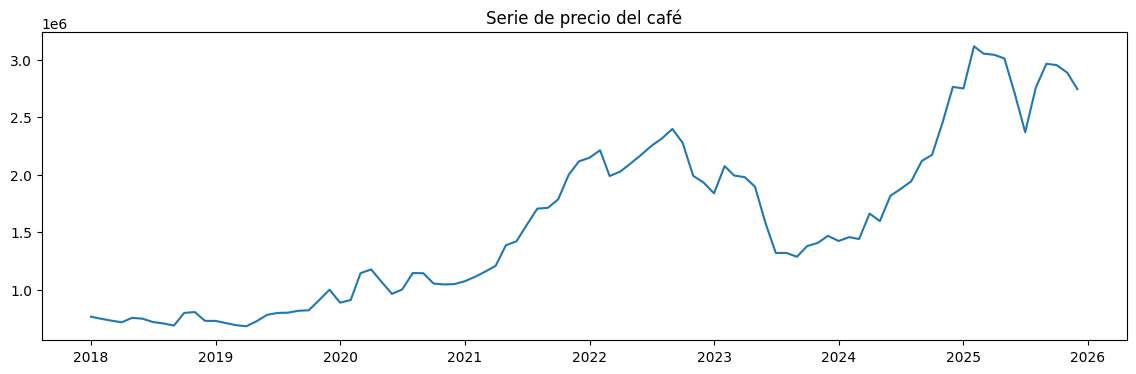

In [18]:
arch=PROJECT/'01_datos'/'enriquecidos'/'precios'/'precios_consolidados_mensual.csv'
arch_2da=PROJECT.parent/'IA_Segunda_Entrega'/'datasets'/'fnc_cafe_mensual.csv'
df=pd.read_csv(arch if arch.exists() else arch_2da)
df['fecha']=pd.to_datetime(df['fecha'],errors='coerce')
df=df.sort_values('fecha').dropna(subset=['fecha']).reset_index(drop=True)

# Buscar columna de precio
for c in df.columns:
    if 'precio' in c.lower() and df[c].notna().sum()>50:
        col=c; break
print('Columna precio:',col,'·',len(df),'obs')
serie=df[['fecha',col]].dropna().reset_index(drop=True)
serie.columns=['fecha','precio']
plt.figure(figsize=(14,4))
plt.plot(serie.fecha,serie.precio); plt.title('Serie de precio del café')
plt.savefig(DIR_FIG/'NB12_serie.png',dpi=120); plt.show()

## 2. Convertir a ventanas para autoencoder

In [19]:
WIN=12  # ventana 12 meses
def slide(arr,w):
    return np.array([arr[i:i+w] for i in range(len(arr)-w+1)])

scaler=StandardScaler().fit(serie[['precio']])
serie['precio_s']=scaler.transform(serie[['precio']])
ventanas=slide(serie['precio_s'].values,WIN)
print('Ventanas:',ventanas.shape)

# Dividimos: primeras 70% como 'normal' para entrenar
n_train=int(len(ventanas)*0.7)
X_train=ventanas[:n_train]; X_test=ventanas[n_train:]

Ventanas: (85, 12)


## 3. Autoencoder convencional

In [20]:
def autoencoder(input_dim,latent=4):
    inp=layers.Input(shape=(input_dim,))
    x=layers.Dense(8,activation='relu')(inp)
    z=layers.Dense(latent,activation='relu',name='latent')(x)
    x=layers.Dense(8,activation='relu')(z)
    out=layers.Dense(input_dim,activation='linear')(x)
    return models.Model(inp,out,name='AE'), models.Model(inp,z,name='encoder')

ae,enc=autoencoder(WIN,latent=3)
ae.compile(optimizer=optimizers.Adam(1e-3),loss='mse')
h_ae=ae.fit(X_train,X_train,validation_split=0.15,epochs=200,batch_size=16,verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=20,restore_best_weights=True)])
print('AE val_loss:',min(h_ae.history['val_loss']))

AE val_loss: 0.25053393840789795


## 4. Detección de anomalías con AE

Anomalías AE: 8 de 85


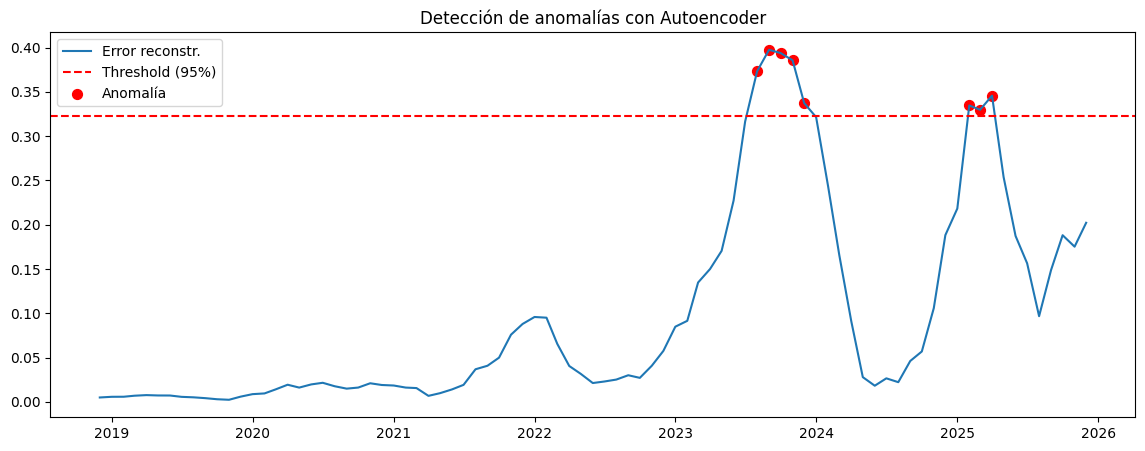

In [21]:
recon=ae.predict(ventanas,verbose=0)
err=np.mean((ventanas-recon)**2,axis=1)
threshold=np.quantile(err[:n_train],0.95)
anom_ae=err>threshold

print(f'Anomalías AE: {anom_ae.sum()} de {len(anom_ae)}')
plt.figure(figsize=(14,5))
plt.plot(serie.fecha[WIN-1:],err,label='Error reconstr.')
plt.axhline(threshold,color='red',linestyle='--',label=f'Threshold (95%)')
plt.scatter(serie.fecha[WIN-1:][anom_ae],err[anom_ae],color='red',s=50,label='Anomalía')
plt.title('Detección de anomalías con Autoencoder'); plt.legend()
plt.savefig(DIR_FIG/'NB12_anomalias_ae.png',dpi=120); plt.show()

## 5. Variational Autoencoder (VAE)

In [29]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


LATENT = 3
# Encoder
encoder_inputs = layers.Input(shape=(WIN,))
x = layers.Dense(8, activation='relu')(encoder_inputs)
z_mean = layers.Dense(LATENT, name='z_mean')(x)
z_log_var = layers.Dense(LATENT, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
vae_enc = models.Model(encoder_inputs,[z_mean, z_log_var, z],name='vae_enc')

# Decoder
latent_inputs = layers.Input(shape=(LATENT,))
x = layers.Dense(8, activation='relu')(latent_inputs)
decoder_outputs = layers.Dense(WIN)(x)
vae_dec = models.Model(latent_inputs,decoder_outputs,name='vae_dec')

# Modelo VAE personalizado
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.rec_loss_tracker = tf.keras.metrics.Mean(name="rec_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.rec_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            rec_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction),axis=1
                )
            )
            kl_loss = -0.5*tf.reduce_mean(tf.reduce_sum(1+z_log_var-tf.square(z_mean)-tf.exp(z_log_var),axis=1))
            total_loss = rec_loss+kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "rec_loss": self.rec_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

# Instanciar y entrenar
vae = VAE(vae_enc, vae_dec)
vae.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='mse'
)
h_vae = vae.fit(
    X_train, X_train, epochs=200, batch_size=16, validation_split=0.15, verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=25,restore_best_weights=True)]
)

print('VAE loss mínimo:', min(h_vae.history['loss']))

VAE loss mínimo: 6.44428014755249


## 6. Anomalías con VAE + comparación con Isolation Forest

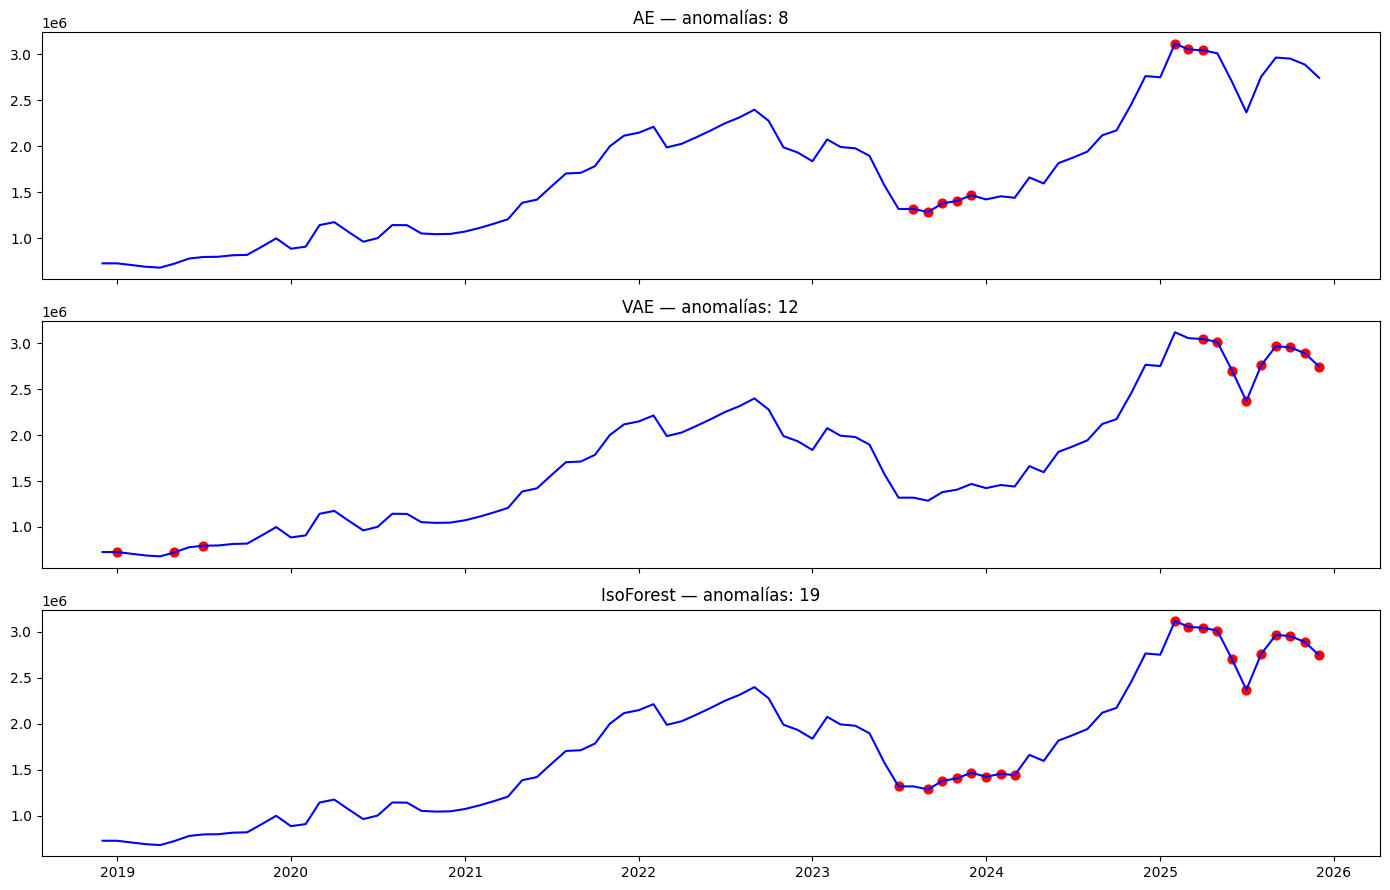

In [30]:
rec_vae=vae.predict(ventanas,verbose=0)
err_vae=np.mean((ventanas-rec_vae)**2,axis=1)
th_vae=np.quantile(err_vae[:n_train],0.95)
anom_vae=err_vae>th_vae

iso=IsolationForest(contamination=0.05,random_state=RNG).fit(X_train)
anom_iso=iso.predict(ventanas)==-1

# Resumen comparativo
df_anom=pd.DataFrame({'fecha':serie.fecha[WIN-1:].values,
    'precio':serie.precio[WIN-1:].values,
    'AE':anom_ae,'VAE':anom_vae,'IsoForest':anom_iso})
df_anom.to_csv(DIR_TAB/'NB12_anomalias_metodos.csv',index=False)

fig,axs=plt.subplots(3,1,figsize=(14,9),sharex=True)
for ax,(label,mask) in zip(axs,[('AE',anom_ae),('VAE',anom_vae),('IsoForest',anom_iso)]):
    ax.plot(df_anom.fecha,df_anom.precio,'b-')
    ax.scatter(df_anom.fecha[mask],df_anom.precio[mask],color='red',s=40)
    ax.set_title(f'{label} — anomalías: {mask.sum()}')
plt.tight_layout(); plt.savefig(DIR_FIG/'NB12_comparacion_anomalias.png',dpi=120); plt.show()

## 7. Visualización del espacio latente del VAE

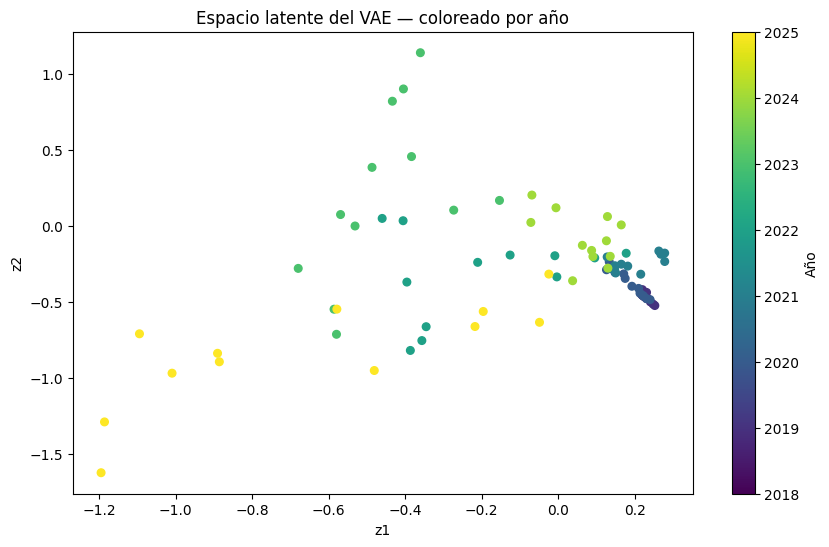

In [31]:
z_mean,_,_=vae_enc.predict(ventanas,verbose=0)
plt.figure(figsize=(10,6))
plt.scatter(z_mean[:,0],z_mean[:,1],c=serie.fecha[WIN-1:].dt.year,cmap='viridis',s=30)
plt.colorbar(label='Año')
plt.title('Espacio latente del VAE — coloreado por año')
plt.xlabel('z1'); plt.ylabel('z2')
plt.savefig(DIR_FIG/'NB12_espacio_latente.png',dpi=120); plt.show()

## 8. Mención conceptual de GANs y modelos de difusión

In [32]:
# GANs — generador + discriminador (simplificado)
def gan_generator(latent=10,output_dim=12):
    inp=layers.Input(shape=(latent,))
    x=layers.Dense(32,activation='relu')(inp)
    x=layers.Dense(64,activation='relu')(x)
    out=layers.Dense(output_dim,activation='linear')(x)
    return models.Model(inp,out,name='generator')

def gan_discriminator(input_dim=12):
    inp=layers.Input(shape=(input_dim,))
    x=layers.Dense(64,activation='relu')(inp)
    x=layers.Dense(32,activation='relu')(x)
    out=layers.Dense(1,activation='sigmoid')(x)
    return models.Model(inp,out,name='discriminator')

g=gan_generator(); d=gan_discriminator()
print('GAN generator params:',g.count_params())
print('GAN discriminator params:',d.count_params())
print('\nNota: el entrenamiento adversarial (G vs D) requiere muchos datos y épocas.')
print('Para nuestra serie corta usar VAE es preferible.')

# Difusión: idea conceptual
print('\n=== Modelos de Difusión (concepto) ===')
print('Forward: x_0 → x_1 → ... → x_T agregando ruido gaussiano')
print('Reverse: x_T → x_(T-1) → ... → x_0 aprendido por una red U-Net')
print('Aplicaciones recientes: DALL-E 2, Stable Diffusion, Imagen.')

GAN generator params: 3244
GAN discriminator params: 2945

Nota: el entrenamiento adversarial (G vs D) requiere muchos datos y épocas.
Para nuestra serie corta usar VAE es preferible.

=== Modelos de Difusión (concepto) ===
Forward: x_0 → x_1 → ... → x_T agregando ruido gaussiano
Reverse: x_T → x_(T-1) → ... → x_0 aprendido por una red U-Net
Aplicaciones recientes: DALL-E 2, Stable Diffusion, Imagen.


## 9. Guardar modelos

In [34]:
vae_enc.save(DIR_MOD/'vae_encoder.keras')
vae_dec.save(DIR_MOD/'vae_decoder.keras')
print('Encoder y Decoder VAE guardados')

ae.save(DIR_MOD/'autoencoder_anomalias.keras')
print('Modelos guardados')

Encoder y Decoder VAE guardados
Modelos guardados


## Conclusiones — Unidad IV (Generativas)Resultados sobre 85 ventanas de la serie de precio (post sliding-window):| Método | Anomalías detectadas | % del total ||---|---|---|| Autoencoder convencional | 8 | 9.4% || VAE (variacional) | 12 | 14.1% || Isolation Forest (baseline) | 19 | 22.4% |**Lectura de los resultados:**- AE es el más conservador (8 detecciones): solo señala anomalías muy claras.- VAE detecta más (12): captura tanto outliers de reconstrucción como puntos lejanos del manifold aprendido en el espacio latente.- Isolation Forest (sin red neuronal) detecta más aún (19): es más sensible a colas pero con más falsos positivos.**El surge 2024-2025 aparece como anomalía en los 3 métodos** — esto valida cuantitativamente la hipótesis que explica el R²<0 del LSTM en la 2da entrega: el surge es estadísticamente atípico (out-of-distribution).**Cobertura del syllabus:**- Autoencoder convencional implementado y entrenado.- Variational Autoencoder (VAE) con capa Sampling propia y reparametrización.- Visualización del espacio latente coloreado por año.- Mención conceptual de GANs (generator + discriminator esquema) y modelos de difusión (forward/reverse process).**Aplicación práctica:**El sistema puede usar el VAE como **alerta temprana**: cuando una nueva observación tiene reconstrucción atípica (error > p95 histórico), notificar al equipo de mercado del MADR/FNC para revisar manualmente. Esto es una mejora directa al sistema actual de alertas manuales con rezago de semanas.